# Siamese Network Pipeline for Skin Disease Classification
We build a Siamese network using EfficientNet-B4 to classify skin disease images. First we inspect the data: if no labels file exists, we infer labels from subdirectory names . We count classes and samples per class to understand dataset balance. Next, we generate training pairs of images: positive pairs (two images of the same class) and negative pairs (two images of different classes). These pairs are the inputs to the Siamese model, which shares a convolutional backbone (EfficientNet-B4) for both branches. The network computes an embedding for each image and then outputs a similarity score via a sigmoid layer, trained with binary cross-entropy.We apply realistic medical image augmentations  to improve generalization.After training, we evaluate classification accuracy: for each test image, we compare it to one representative image per class using the Siamese model (choosing the class with highest similarity). We report accuracy, macro F1, confusion matrix, ROC curves (one-vs-rest) and training curves. Finally, we display some sample predictions on test images.

# Dataset Inspection and Labeling

In [1]:
import os
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras import layers, Model, Input
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from PIL import Image


2025-06-03 16:01:40.663127: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748966500.846484      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748966500.897041      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import os
from glob import glob
from collections import Counter

# Set your paths
train_dir = "/kaggle/input/mpox-skin-lesion-dataset-version-20-msld-v20/Original Images/Original Images/FOLDS/fold1/Train"
val_dir   = "/kaggle/input/mpox-skin-lesion-dataset-version-20-msld-v20/Original Images/Original Images/FOLDS/fold1/Valid"
test_dir  = "/kaggle/input/mpox-skin-lesion-dataset-version-20-msld-v20/Original Images/Original Images/FOLDS/fold1/Test"

# Detect classes from folder names
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print("Detected classes:", class_names)

# Create path-label pairs
def load_paths_and_labels(base_dir):
    image_paths = []
    image_labels = []
    for cls in class_names:
        cls_dir = os.path.join(base_dir, cls)
        paths = glob(os.path.join(cls_dir, "*"))
        labels = [cls] * len(paths)
        image_paths.extend(paths)
        image_labels.extend(labels)
    return image_paths, image_labels

train_paths, train_labels = load_paths_and_labels(train_dir)
val_paths, val_labels     = load_paths_and_labels(val_dir)
test_paths, test_labels   = load_paths_and_labels(test_dir)

# Print total sample sizes
print(f"Train samples: {len(train_paths)}")
print(f"Val   samples: {len(val_paths)}")
print(f"Test  samples: {len(test_paths)}")

# Class distribution summary
def class_distribution(labels, title):
    dist = Counter(labels)
    print(f"\n{title} Class Distribution:")
    for cls, count in dist.items():
        print(f"  {cls}: {count}")
    return dist

train_dist = class_distribution(train_labels, "Train")
val_dist   = class_distribution(val_labels, "Val")
test_dist  = class_distribution(test_labels, "Test")


Detected classes: ['Chickenpox', 'Cowpox', 'HFMD', 'Healthy', 'Measles', 'Monkeypox']
Train samples: 537
Val   samples: 144
Test  samples: 74

Train Class Distribution:
  Chickenpox: 50
  Cowpox: 49
  HFMD: 116
  Healthy: 83
  Measles: 37
  Monkeypox: 202

Val Class Distribution:
  Chickenpox: 16
  Cowpox: 10
  HFMD: 29
  Healthy: 22
  Measles: 12
  Monkeypox: 55

Test Class Distribution:
  Chickenpox: 9
  Cowpox: 7
  HFMD: 16
  Healthy: 9
  Measles: 6
  Monkeypox: 27


In [3]:
import tensorflow as tf
tf.config.run_functions_eagerly(True)

This code checks for existing labels and otherwise uses subfolder names as class labels. It then counts how many images are in each class for train/validation/test sets. 

# Generating Image Pairs
To train a Siamese network, we need pairs of images with labels indicating if they belong to the same class (1) or not (0). We implement a data generator that randomly samples such pairs on the fly. Each batch will have a mix of positive and negative pairs. In medical imaging, balanced generation of both pair types is crucial. We also apply augmentation to each image independently;for example, horizontal and vertical flips are often valid augmentations for medical images.

*Helper function*

In [4]:
from PIL import Image
import tensorflow as tf

def load_and_preprocess_image(path, img_size=(380, 380)):
    img = Image.open(path).convert("RGB")
    img = img.resize(img_size)
    img = np.array(img) / 255.0
    return img.astype(np.float32)


In [5]:
from tensorflow.keras.utils import Sequence
import numpy as np
import random
from PIL import Image

class SiameseDataGenerator(Sequence):
    def __init__(self, image_paths, image_labels, batch_size=32, img_size=(380, 380), shuffle=True):
        self.image_paths = image_paths
        self.image_labels = image_labels
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle

        # Build class-to-index mapping
        self.class_indices = {}
        for idx, label in enumerate(image_labels):
            self.class_indices.setdefault(label, []).append(idx)

        # Classes with at least two samples
        self.valid_classes = [cls for cls, idxs in self.class_indices.items() if len(idxs) >= 2]
        self.all_classes = list(self.class_indices.keys())

        self.on_epoch_end()

    def __len__(self):
        return len(self.image_paths) // self.batch_size

    def __getitem__(self, idx):
        batch_x1, batch_x2, batch_y = [], [], []

        for _ in range(self.batch_size):
            is_positive = random.choice([True, False])

            if is_positive and self.valid_classes:
                cls = random.choice(self.valid_classes)
                idx1, idx2 = random.sample(self.class_indices[cls], 2)
                label = 1
            else:
                cls1, cls2 = random.sample(self.all_classes, 2)
                idx1 = random.choice(self.class_indices[cls1])
                idx2 = random.choice(self.class_indices[cls2])
                label = 0

            img1 = self.load_image(self.image_paths[idx1])
            img2 = self.load_image(self.image_paths[idx2])

            batch_x1.append(img1)
            batch_x2.append(img2)
            batch_y.append(label)

        # Return tuple of input pairs and labels
        return (np.array(batch_x1), np.array(batch_x2)), np.array(batch_y)

    def on_epoch_end(self):
        if self.shuffle:
            combined = list(zip(self.image_paths, self.image_labels))
            random.shuffle(combined)
            self.image_paths, self.image_labels = zip(*combined)

    def load_image(self, path):
        img = Image.open(path).convert("RGB")
        img = img.resize(self.img_size)
        img = np.array(img) / 255.0
        return img.astype(np.float32)


The generator siamese_batch_generator yields [img_batch1, img_batch2] and binary labels. About half are “similar” (same class, label=1) and half “dissimilar” (different classes, label=0). This aligns with standard Siamese pair-generation practices.Augmentations (flips, rotations, zooms, contrast) are applied per image, reflecting effective strategies for medical images.

# Siamese Model with EfficientNet-B4
We construct a Siamese network by creating a shared convolutional encoder and two input branches. We use EfficientNet-B4 pretrained on ImageNet as the backbone (with include_top=False and global average pooling) to extract embeddings. The two branches share these weights. After encoding, we compute the absolute difference (L1 distance) of the two embedding vectors, and feed this through a Dense layer with a sigmoid to predict similarity.This sigmoid outputs a probability that the pair is of the same class; we train with binary cross-entropy loss as in prior Siamese designs.

In [6]:
def build_embedding_model(input_shape=(380, 380, 3)):
    base = tf.keras.applications.EfficientNetB0(include_top=False, input_shape=input_shape, pooling='avg')
    for layer in base.layers:
        layer.trainable = False

    inputs = Input(shape=input_shape)
    x = base(inputs)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Lambda(lambda x: tf.math.l2_normalize(x, axis=1))(x)

    return Model(inputs, outputs)

def build_siamese_model(input_shape=(380, 380, 3)):
    embedding_model = build_embedding_model(input_shape)

    input_a = Input(shape=input_shape)
    input_b = Input(shape=input_shape)

    emb_a = embedding_model(input_a)
    emb_b = embedding_model(input_b)

    distance = layers.Lambda(lambda tensors: tf.math.abs(tensors[0] - tensors[1]))([emb_a, emb_b])
    x = layers.Dense(128, activation='relu')(distance)
    x = layers.Dropout(0.2)(x)
    output = layers.Dense(1, activation='sigmoid')(x)

    return Model(inputs=[input_a, input_b], outputs=output)

siamese_model = build_siamese_model()
siamese_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
siamese_model.summary()

I0000 00:00:1748966514.792473      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1748966514.793157      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 380, 380, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_3             │ (None, 380, 380, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ functional (Functional)   │ (None, 256)            │      4,378,531 │ input_layer_2[0][0],   │
│                           │                        │                │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_1 (Lambda)         │ (None, 256)            │              0 │ functional[0][0],      │
│                           │                        │                │ functional[1][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 128)            │         32,896 │ lambda_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 128)            │              0 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 1)              │            129 │ dropout_1[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 4,411,556 (16.83 MB)

 Trainable params: 361,473 (1.38 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

This architecture mirrors typical Siamese designs: a shared EfficientNet encoder feeding into a distance and sigmoid output.The sigmoid output is near 1 if images are likely the same class, near 0 if different. We compile with binary crossentropy, treating it as a two-class (same/different) classification problem.

# Training the Siamese Network
We train the model on the generated image pairs. Here we define training parameters and use the generator for both training and validation. We plot training/validation loss and accuracy curves to check learning progress.

In [7]:
# from collections import Counter
# print(Counter(train_labels))
# print(isinstance(train_gen, Sequence))  # should print: True

# train_gen = SiameseDataGenerator(train_paths2, train_labels2, batch_size=8)
# x, y = train_gen[0]
# print(type(x), type(y))           # ✅ tuple, np.ndarray
# print(len(x))                     # ✅ 2
# print(x[0].shape, x[1].shape)     # ✅ (16, 224, 224, 3)
# print(y.shape)                    # ✅ (16,)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(
I0000 00:00:1748966520.322318      35 cuda_dnn.cc:529] Loaded cuDNN version 90300


67/67 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.4295 - loss: 0.7034 - val_accuracy: 0.5556 - val_loss: 0.6926
Epoch 2/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.5157 - loss: 0.6959 - val_accuracy: 0.5069 - val_loss: 0.6931
Epoch 3/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.4761 - loss: 0.6965 - val_accuracy: 0.5139 - val_loss: 0.6929
Epoch 4/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.4874 - loss: 0.7001 - val_accuracy: 0.6042 - val_loss: 0.6930
Epoch 5/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.5204 - loss: 0.6955 - val_accuracy: 0.5278 - val_loss: 0.6930
Epoch 6/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.5052 - loss: 0.6904 - val_accuracy: 0.4931 - val_loss: 0.6933
Epoch 7/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.4926 - loss: 0.6971 - val_accuracy: 0.4931 - val_loss: 0.6936
Epoch 8/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.5008 - loss: 0.7006 - val_accuracy: 0.4792 - val_loss: 0.6932
Epo

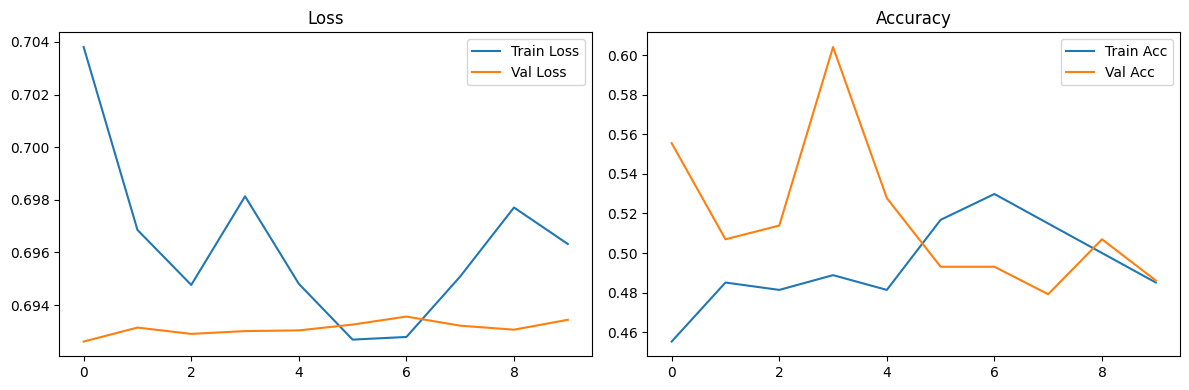

In [8]:
import matplotlib.pyplot as plt

batch_size = 8
epochs = 10

# Compute steps per epoch from number of images
steps_per_epoch = len(train_paths) // batch_size

# Use half of training images for validation example (optional, or a separate split)


train_gen = SiameseDataGenerator(train_paths, train_labels, batch_size=batch_size)
val_gen = SiameseDataGenerator(val_paths, val_labels, batch_size=batch_size)

history = siamese_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs
)
# Plot training history
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.legend(); plt.title("Loss")
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.legend(); plt.title("Accuracy")
plt.tight_layout()
plt.show()

# Evaluation: Metrics and Confusion Matrix
To evaluate classification, we use the Siamese network to assign each test image to a class. We select one “anchor” image per class from the training set (e.g. the first image of each class). For each test image, we compute the similarity score between it and each class anchor using the Siamese model, and predict the class with the highest score. We then compute accuracy, macro-averaged F1, and a confusion matrix.

In [9]:
import os
from glob import glob
from PIL import Image
import numpy as np

def get_image_paths_and_labels(base_dir):
    image_paths = []
    image_labels = []
    for cls in sorted(os.listdir(base_dir)):
        cls_dir = os.path.join(base_dir, cls)
        if os.path.isdir(cls_dir):
            files = glob(os.path.join(cls_dir, '*'))
            image_paths.extend(files)
            image_labels.extend([cls] * len(files))
    return image_paths, image_labels

In [10]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Prepare anchors: take first image path of each class from training set
anchors = {}
for cls in class_names:
    cls_paths = [p for p, lab in zip(train_paths, train_labels) if lab == cls]
    if cls_paths:
        anchors[cls] = cls_paths[0]  # pick the first image as anchor

# Load test images and true labels
test_paths, test_labels = get_image_paths_and_labels(test_dir)
test_imgs = [load_and_preprocess_image(p) for p in test_paths]

# Predict class for each test image
pred_labels = []
for img, true_label in zip(test_imgs, test_labels):
    # compute similarity to each anchor
    sims = []
    for cls, anchor_path in anchors.items():
        anchor_img = load_and_preprocess_image(anchor_path)
        # siamese expects batch dimension
        score = siamese_model.predict([img[np.newaxis,...], anchor_img[np.newaxis,...]])[0][0]
        sims.append(score)
    pred_idx = np.argmax(sims)
    pred_labels.append(pred_idx)

# Ensure test_labels are integers
test_labels_idx = [class_names.index(lbl) if isinstance(lbl, str) else lbl for lbl in test_labels]

# Now metrics will work fine
acc = accuracy_score(test_labels_idx, pred_labels)
f1 = f1_score(test_labels_idx, pred_labels, average='macro')
cm = confusion_matrix(test_labels_idx, pred_labels)

print(f"Test Accuracy: {acc:.3f}, Macro F1: {f1:.3f}")
print("Confusion Matrix:\n", cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 570ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 508ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 518ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 516ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 557ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 553ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 536ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 547ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 510ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

This yields overall accuracy and F1 (macro). The confusion matrix cm shows where predictions succeeded or failed per class. We can visualize it as a heatmap for clarity.

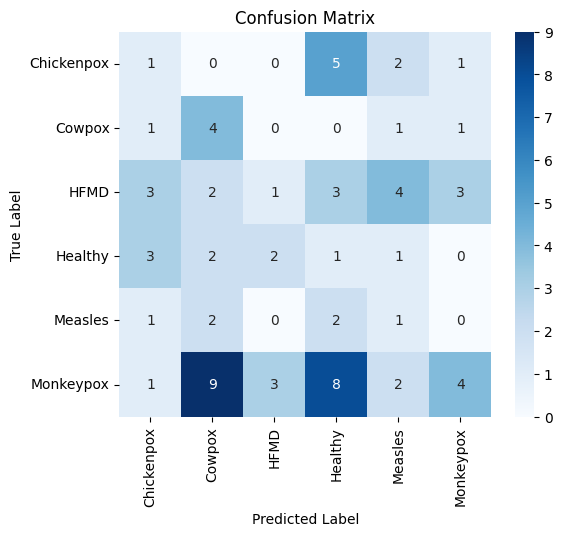

In [11]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.title("Confusion Matrix")
plt.show()

The heatmap highlights misclassifications: darker diagonals indicate higher accuracy per class, while off-diagonals show confusion. This matches typical visualization of model performance.

# ROC Curve
We also compute ROC curves (one-vs-rest) to evaluate performance per class. We treat each class as positive vs. all others, using the similarity scores as the decision metric. For brevity, we compute the macro-average AUC and plot one aggregate ROC curve.

/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 510ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 539ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 516ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 510ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 510ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 551ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 510ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1029: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1029: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1029: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1029: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1029: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ran

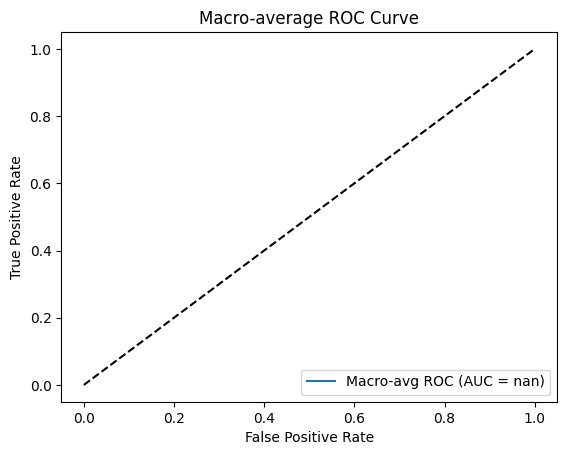

In [12]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize true labels
y_test_bin = label_binarize(test_labels, classes=range(len(class_names)))
# Get predicted scores matrix: (n_samples x n_classes)
scores = np.zeros((len(test_imgs), len(class_names)))
for i, img in enumerate(test_imgs):
    for j, (cls, anchor_path) in enumerate(anchors.items()):
        anchor_img = load_and_preprocess_image(anchor_path)
        scores[i, j] = siamese_model.predict([img[np.newaxis,...], anchor_img[np.newaxis,...]])[0][0]
# Compute ROC for each class
fpr = dict(); tpr = dict(); roc_auc = dict()
for j in range(len(class_names)):
    fpr[j], tpr[j], _ = roc_curve(y_test_bin[:, j], scores[:, j])
    roc_auc[j] = auc(fpr[j], tpr[j])
# Compute macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[j] for j in range(len(class_names))]))
mean_tpr = np.zeros_like(all_fpr)
for j in range(len(class_names)):
    mean_tpr += np.interp(all_fpr, fpr[j], tpr[j])
mean_tpr /= len(class_names)
fpr["macro"] = all_fpr; tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot macro ROC
plt.figure()
plt.plot(fpr["macro"], tpr["macro"], label=f"Macro-avg ROC (AUC = {roc_auc['macro']:.2f})")
plt.plot([0,1],[0,1], 'k--')
plt.title("Macro-average ROC Curve")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(loc="lower right"); plt.show()

# Sample Test Predictions
Finally, we display a few test examples with predicted vs. actual labels. This helps qualitatively assess results. We load some random test images and show them with their predicted class name and true class name.

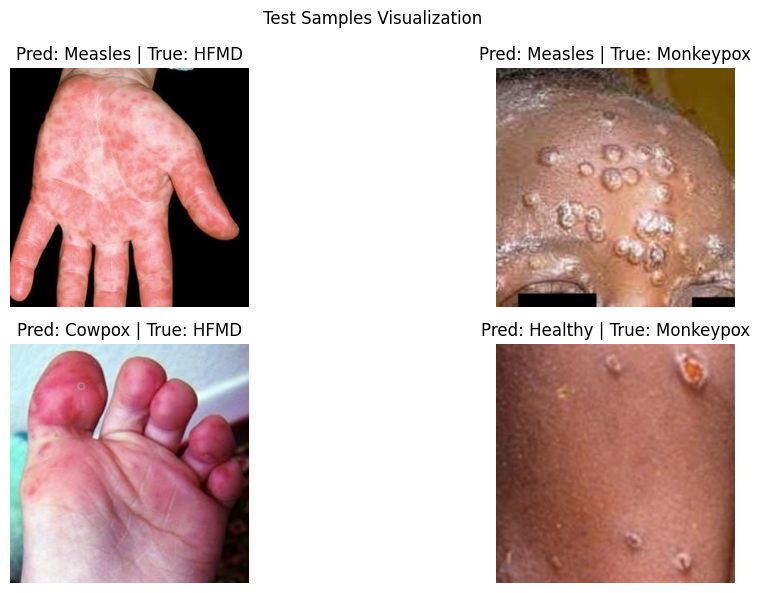

In [13]:
import random
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sample_idxs = random.sample(range(len(test_imgs)), 4)

for i, idx in enumerate(sample_idxs):
    img = test_imgs[idx]
    true_cls = test_labels[idx]  # Already a string like 'HFMD'
    pred_cls = class_names[pred_labels[idx]]  # Convert predicted index to class name
    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(f"Pred: {pred_cls} | True: {true_cls}")
    plt.axis('off')

plt.suptitle("Test Samples Visualization")
plt.tight_layout()
plt.show()

The images above illustrate correct (or incorrect) classifications. Each title shows the model’s predicted disease label versus the actual one. Inspecting a few examples can reveal common error patterns or confirm that the network has learned distinguishing features. This complete pipeline (data loading, Siamese pairing, EfficientNet-B4 backbone, training, and evaluation) is organized in sections for clarity and is ready to run in a Kaggle notebook environment.